In [1]:
%cd NISP-Dataset/Hindi_master

/data/himanshu/NISP-Dataset/Hindi_master


/home/himanshu/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
dataset_path = '/data/himanshu/NISP-Dataset/Hindi_master'  # Update this path as needed
os.chdir(dataset_path)

In [3]:
import pandas as pd

# Define the path to the speaker info file (adjust if necessary)
spkr_info_path = '../total_spkrinfo.list'
spkr_columns = ['Speaker_ID', 'Gender', 'Mother_Tongue', 'Height_cm',
                'Shoulder_size_cm', 'Waist_size_cm', 'Weight_kg', 'Age_y',
                'Native_State', 'Native_District']

# Load the speaker info into a DataFrame
spkr_info_df = pd.read_csv(spkr_info_path, sep=' ', names=spkr_columns)
spkr_info_df = spkr_info_df.drop(index=0)
print("Speaker Metadata (first 5 rows):")
print(spkr_info_df.head())

Speaker Metadata (first 5 rows):
  Speaker_ID  Gender Mother_Tongue Height_cm Shoulder_size_cm Waist_size_cm  \
1   Hin_0001  Female         Hindi       163               40          89.5   
2   Hin_0002  Female         Hindi     154.5             36.5            72   
3   Hin_0003    Male         Hindi     167.5             40.5            78   
4   Hin_0004    Male         Hindi       176               43          91.5   
5   Hin_0005  Female         Hindi       153             40.5            96   

  Weight_kg  Age_y    Native_State Native_District  
1      58.5  24.24       Rajasthan          Jaipur  
2      50.9  26.06  Madhya_Pradesh          Indore  
3      56.6  21.51         Haryana       Faridabad  
4      77.6  21.09    Chhattisgarh        Bilaspur  
5      80.2  27.39   Uttar_Pradesh    Kanpur_Nagar  


In [4]:
import os

In [5]:
import glob

In [6]:
# Define the folder containing merged audio files
audio_folder = "../Merged_Audio"

# List all .wav files in the merged folder
audio_files = glob.glob(os.path.join(audio_folder, "*.wav"))

# Build a list to store audio file information
audio_data = []
for file_path in audio_files:
    file_name = os.path.basename(file_path)
    # Expected filename format: Hin_0067_Hin_m_0014.wav
    parts = file_name.split('_')
    if len(parts) >= 2:
        # Construct the full speaker ID from the first two tokens, e.g., "Hin_0067"
        speaker_id_full = f"{parts[0]}_{parts[1]}"

        audio_data.append({
            'Speaker_ID': speaker_id_full,

            'File_Path': file_path
        })
    else:
        print("Unexpected filename format:", file_name)

# Create a DataFrame from the audio data
audio_df = pd.DataFrame(audio_data)
print("Audio DataFrame (first 5 rows):")
print(audio_df.head())

Audio DataFrame (first 5 rows):
  Speaker_ID                                File_Path
0   Hin_0092  ../Merged_Audio/Hin_0092_Hin_f_0008.wav
1   Hin_0077  ../Merged_Audio/Hin_0077_Eng_f_7341.wav
2   Hin_0093  ../Merged_Audio/Hin_0093_Hin_f_0023.wav
3   Hin_0020  ../Merged_Audio/Hin_0020_Eng_m_5447.wav
4   Hin_0013  ../Merged_Audio/Hin_0013_Eng_m_5222.wav


In [7]:
audio_df['Speaker_ID'] = audio_df['Speaker_ID'].astype(str)
spkr_info_df['Speaker_ID'] = spkr_info_df['Speaker_ID'].astype(str)


merged_df = pd.merge(audio_df, spkr_info_df[['Speaker_ID', 'Native_State']],
                     on='Speaker_ID', how='left')

# Select only the desired columns: the audio file path and the corresponding Native_State.
final_df = merged_df[['File_Path', 'Speaker_ID', 'Native_State']]
print("Final Dataset (first 5 rows):")
print(final_df.head())

Final Dataset (first 5 rows):
                                 File_Path Speaker_ID   Native_State
0  ../Merged_Audio/Hin_0092_Hin_f_0008.wav   Hin_0092  Uttar_Pradesh
1  ../Merged_Audio/Hin_0077_Eng_f_7341.wav   Hin_0077    Maharashtra
2  ../Merged_Audio/Hin_0093_Hin_f_0023.wav   Hin_0093    Maharashtra
3  ../Merged_Audio/Hin_0020_Eng_m_5447.wav   Hin_0020  Uttar_Pradesh
4  ../Merged_Audio/Hin_0013_Eng_m_5222.wav   Hin_0013          Bihar


In [8]:
df= final_df
df.head()

,File_Path,Speaker_ID,Native_State
0,../Merged_Audio/Hin_0092_Hin_f_0008.wav,Hin_0092,Uttar_Pradesh
1,../Merged_Audio/Hin_0077_Eng_f_7341.wav,Hin_0077,Maharashtra
2,../Merged_Audio/Hin_0093_Hin_f_0023.wav,Hin_0093,Maharashtra
3,../Merged_Audio/Hin_0020_Eng_m_5447.wav,Hin_0020,Uttar_Pradesh
4,../Merged_Audio/Hin_0013_Eng_m_5222.wav,Hin_0013,Bihar


In [9]:
import os
import pandas as pd
import numpy as np
import librosa
import torch
import soundfile as sf

from datasets import Dataset
from transformers import (
    AutoProcessor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:


# Rename columns for consistency
df = df.rename(columns={
    "File_Path": "file_path",
    "Native_State": "label_text"
})

dataset = Dataset.from_pandas(df)

In [11]:
df.head()

,file_path,Speaker_ID,label_text
0,../Merged_Audio/Hin_0092_Hin_f_0008.wav,Hin_0092,Uttar_Pradesh
1,../Merged_Audio/Hin_0077_Eng_f_7341.wav,Hin_0077,Maharashtra
2,../Merged_Audio/Hin_0093_Hin_f_0023.wav,Hin_0093,Maharashtra
3,../Merged_Audio/Hin_0020_Eng_m_5447.wav,Hin_0020,Uttar_Pradesh
4,../Merged_Audio/Hin_0013_Eng_m_5222.wav,Hin_0013,Bihar


In [12]:
df.shape

(7839, 3)

In [13]:
labels = sorted(df["label_text"].unique())

label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

def encode_labels(batch):
    batch["label"] = label2id[batch["label_text"]]
    return batch

dataset = dataset.map(encode_labels)

Map:   0%|          | 0/7839 [00:00<?, ? examples/s]

In [14]:
def load_audio(batch):
    audio, _ = librosa.load(batch["file_path"], sr=16000)
    batch["audio"] = audio
    return batch

dataset = dataset.map(load_audio)

Map:   0%|          | 0/7839 [00:00<?, ? examples/s]

/usr/lib/python3/dist-packages/paramiko/pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/usr/lib/python3/dist-packages/paramiko/transport.py:261: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


In [15]:
dataset = dataset.train_test_split(test_size=0.2)

train_dataset = dataset["train"]
val_dataset = dataset["test"]

In [16]:
from transformers import Wav2Vec2FeatureExtractor

processor = Wav2Vec2FeatureExtractor.from_pretrained(
    "facebook/wav2vec2-xls-r-300m"
)

/home/himanshu/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [17]:
from transformers import (
    Wav2Vec2FeatureExtractor,
    AutoModelForAudioClassification
)

model_name = "facebook/wav2vec2-xls-r-300m"

processor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)

model = AutoModelForAudioClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    label2id=label2id,
    id2label=id2label
)

model.freeze_feature_encoder()

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-xls-r-300m and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
import numpy as np

TARGET_LENGTH = 16000 * 10  # 10 seconds (160k samples)

def preprocess(batch):
    audio = batch["audio"]

    # 🔹 Case 1: Audio longer than 10 sec → Random crop (recommended)
    if len(audio) > TARGET_LENGTH:
        start = np.random.randint(0, len(audio) - TARGET_LENGTH)
        audio = audio[start:start + TARGET_LENGTH]

    # 🔹 Case 2: Audio shorter than 10 sec → Pad with zeros
    elif len(audio) < TARGET_LENGTH:
        pad_length = TARGET_LENGTH - len(audio)
        audio = np.pad(audio, (0, pad_length), mode='constant')

    # 🔹 Convert to model input
    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    batch["input_values"] = inputs.input_values[0]
    return batch

In [19]:
train_dataset = train_dataset.map(
    preprocess,
    remove_columns=["audio", "file_path", "label_text"]
)

val_dataset = val_dataset.map(
    preprocess,
    remove_columns=["audio", "file_path", "label_text"]
)

Map:   0%|          | 0/6271 [00:00<?, ? examples/s]

Map:   0%|          | 0/1568 [00:00<?, ? examples/s]

In [20]:
from dataclasses import dataclass
from typing import List, Dict

@dataclass
class DataCollator:
    processor: AutoProcessor

    def __call__(self, features: List[Dict]):
        input_values = [f["input_values"] for f in features]
        labels = [f["label"] for f in features]

        batch = self.processor.pad(
            {"input_values": input_values},
            return_tensors="pt",
            padding=True
        )

        batch["labels"] = torch.tensor(labels)
        return batch

data_collator = DataCollator(processor)

In [21]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        logits = predictions[0]
    else:
        logits = predictions

    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    accuracy = accuracy_score(labels, preds)

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [22]:
training_args = TrainingArguments(
    output_dir="./xlsr-dialect",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    num_train_epochs=10,
    learning_rate=1e-4,
    warmup_steps=500,
    fp16=True,
    save_total_limit=2
)

In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=processor,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/home/himanshu/.local/lib/python3.10/site-packages/accelerate/accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [24]:
import torch
torch.cuda.empty_cache()

In [25]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,2.598100,2.521570,0.213648,0.075220,0.045645,0.213648
2,2.542500,2.521505,0.213648,0.075220,0.045645,0.213648
3,1.779700,1.767598,0.403061,0.333000,0.351585,0.403061
4,0.798100,0.612726,0.826531,0.811646,0.810956,0.826531
5,0.353700,0.310441,0.910077,0.898830,0.920400,0.910077
6,0.149000,0.084003,0.981505,0.981405,0.981815,0.981505
7,0.131200,0.089146,0.984056,0.984052,0.984381,0.984056
8,0.069700,0.075711,0.989796,0.989759,0.989909,0.989796


/home/himanshu/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/himanshu/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/himanshu/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/himanshu/.

KeyboardInterrupt: 

In [26]:
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': 0.07571089267730713, 'eval_accuracy': 0.9897959183673469, 'eval_f1': 0.9897593693720766, 'eval_precision': 0.9899092886206315, 'eval_recall': 0.9897959183673469}


In [27]:
train_outputs = trainer.predict(train_dataset)

if isinstance(train_outputs.predictions, tuple):
    train_logits = train_outputs.predictions[0]
else:
    train_logits = train_outputs.predictions

train_labels = train_outputs.label_ids
train_preds = np.argmax(train_logits, axis=-1)

train_accuracy = accuracy_score(train_labels, train_preds)
print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.9990


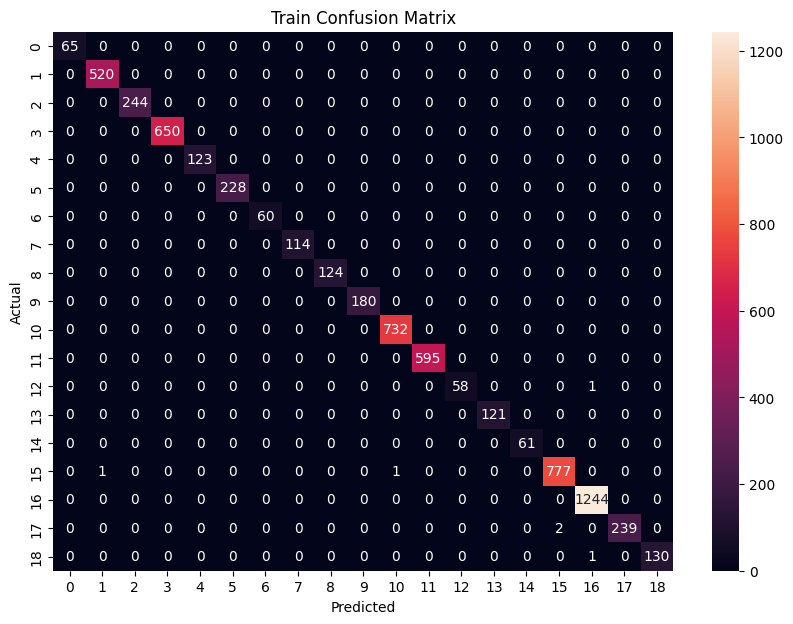

In [28]:
cm_train = confusion_matrix(train_labels, train_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_train, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Train Confusion Matrix')
plt.show()

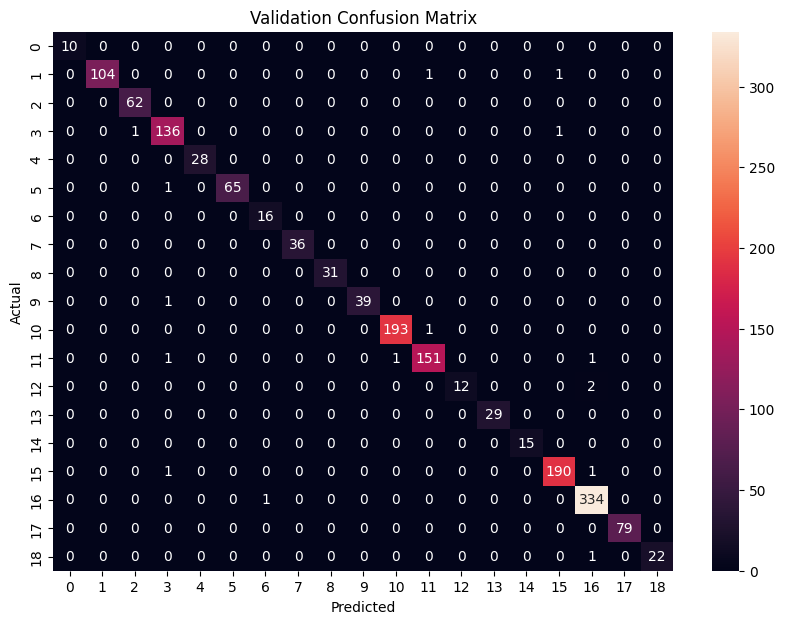

In [29]:
val_outputs = trainer.predict(val_dataset)

if isinstance(val_outputs.predictions, tuple):
    val_logits = val_outputs.predictions[0]
else:
    val_logits = val_outputs.predictions

val_labels = val_outputs.label_ids
val_preds = np.argmax(val_logits, axis=-1)

cm_val = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_val, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Validation Confusion Matrix')
plt.show()